In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/ieee-fraud-detection/sample_submission.csv
/kaggle/input/ieee-fraud-detection/test_identity.csv
/kaggle/input/ieee-fraud-detection/train_identity.csv
/kaggle/input/ieee-fraud-detection/test_transaction.csv
/kaggle/input/ieee-fraud-detection/train_transaction.csv


# Loading Libraries

In [2]:
import seaborn as sns
import pickle
import matplotlib.pyplot as plt
from sklearn.preprocessing import LabelEncoder
from imblearn.over_sampling import SMOTE
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import r2_score, accuracy_score, roc_curve, auc

# Loading Dataset

In [3]:
!ls ../input/ieee-fraud-detection/

sample_submission.csv  test_transaction.csv  train_transaction.csv
test_identity.csv      train_identity.csv


In [4]:
train_id = pd.read_csv("../input/ieee-fraud-detection/train_identity.csv")
train_tra = pd.read_csv("../input/ieee-fraud-detection/train_transaction.csv")
test_id = pd.read_csv("../input/ieee-fraud-detection/test_identity.csv")
test_tra = pd.read_csv("../input/ieee-fraud-detection/test_transaction.csv")

data = train_tra.merge(train_id, how='left')
test = test_tra.merge(test_id, how='left')
# data = pd.concat([train_id,train_tra])
# test = pd.concat([test_id,test_tra])
# train_id.head()

In [5]:
a=['id_17', 'id_02', 'id_19', 'id_05']
for i in a:
    data.drop(i, inplace = True, axis = 1)

In [6]:
a=['isFraud', 'id_17', 'id_02', 'id_19', 'id_05']
for i in a:
    print(i in data)

True
False
False
False
False


In [7]:
test.head()

,TransactionID,TransactionDT,TransactionAmt,ProductCD,card1,card2,card3,card4,card5,card6,...,id-31,id-32,id-33,id-34,id-35,id-36,id-37,id-38,DeviceType,DeviceInfo
0,3663549,18403224,31.95,W,10409,111.0,150.0,visa,226.0,debit,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,3663550,18403263,49.00,W,4272,111.0,150.0,visa,226.0,debit,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,3663551,18403310,171.00,W,4476,574.0,150.0,visa,226.0,debit,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,3663552,18403310,284.95,W,10989,360.0,150.0,visa,166.0,debit,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,3663553,18403317,67.95,W,18018,452.0,150.0,mastercard,117.0,debit,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [55]:
test_id = test['TransactionID']
test_id

0         3663549
1         3663550
2         3663551
3         3663552
4         3663553
           ...   
506686    4170235
506687    4170236
506688    4170237
506689    4170238
506690    4170239
Name: TransactionID, Length: 506691, dtype: int64

In [9]:
data.head()

,TransactionID,isFraud,TransactionDT,TransactionAmt,ProductCD,card1,card2,card3,card4,card5,...,id_31,id_32,id_33,id_34,id_35,id_36,id_37,id_38,DeviceType,DeviceInfo
0,2987000,0,86400,68.5,W,13926,NaN,150.0,discover,142.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2987001,0,86401,29.0,W,2755,404.0,150.0,mastercard,102.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2987002,0,86469,59.0,W,4663,490.0,150.0,visa,166.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,2987003,0,86499,50.0,W,18132,567.0,150.0,mastercard,117.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,2987004,0,86506,50.0,H,4497,514.0,150.0,mastercard,102.0,...,samsung browser 6.2,32.0,2220x1080,match_status:2,T,F,T,T,mobile,SAMSUNG SM-G892A Build/NRD90M


In [10]:
'isFraud' in data.columns

True

In [11]:
test.head()

,TransactionID,TransactionDT,TransactionAmt,ProductCD,card1,card2,card3,card4,card5,card6,...,id-31,id-32,id-33,id-34,id-35,id-36,id-37,id-38,DeviceType,DeviceInfo
0,3663549,18403224,31.95,W,10409,111.0,150.0,visa,226.0,debit,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,3663550,18403263,49.00,W,4272,111.0,150.0,visa,226.0,debit,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,3663551,18403310,171.00,W,4476,574.0,150.0,visa,226.0,debit,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,3663552,18403310,284.95,W,10989,360.0,150.0,visa,166.0,debit,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,3663553,18403317,67.95,W,18018,452.0,150.0,mastercard,117.0,debit,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [12]:
del train_tra, train_id, test_tra, test_id

In [13]:
data.shape

(590540, 430)

# Preprocessing

In [14]:
data.isnull().sum()/len(data) * 100

TransactionID      0.000000
isFraud            0.000000
TransactionDT      0.000000
TransactionAmt     0.000000
ProductCD          0.000000
                    ...    
id_36             76.126088
id_37             76.126088
id_38             76.126088
DeviceType        76.155722
DeviceInfo        79.905510
Length: 430, dtype: float64

In [15]:
for i in data.columns:
    if data[i].isnull().sum() / len(data) * 100 > 80:
#         print(i)
        data.drop(i, inplace = True, axis = 1)

In [16]:
data.head()

,TransactionID,isFraud,TransactionDT,TransactionAmt,ProductCD,card1,card2,card3,card4,card5,...,id_20,id_28,id_29,id_31,id_35,id_36,id_37,id_38,DeviceType,DeviceInfo
0,2987000,0,86400,68.5,W,13926,NaN,150.0,discover,142.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2987001,0,86401,29.0,W,2755,404.0,150.0,mastercard,102.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2987002,0,86469,59.0,W,4663,490.0,150.0,visa,166.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,2987003,0,86499,50.0,W,18132,567.0,150.0,mastercard,117.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,2987004,0,86506,50.0,H,4497,514.0,150.0,mastercard,102.0,...,144.0,New,NotFound,samsung browser 6.2,T,F,T,T,mobile,SAMSUNG SM-G892A Build/NRD90M


In [17]:
data.isnull().sum()/len(data) * 100

TransactionID      0.000000
isFraud            0.000000
TransactionDT      0.000000
TransactionAmt     0.000000
ProductCD          0.000000
                    ...    
id_36             76.126088
id_37             76.126088
id_38             76.126088
DeviceType        76.155722
DeviceInfo        79.905510
Length: 356, dtype: float64

In [18]:
for i in data.columns:
    data[i] = data[i].fillna(data[i].mode()[0])

In [19]:
data.describe()

,TransactionID,isFraud,TransactionDT,TransactionAmt,card1,card2,card3,card5,addr1,addr2,...,V317,V318,V319,V320,V321,id_01,id_06,id_11,id_13,id_20
count,5.905400e+05,590540.000000,5.905400e+05,590540.000000,590540.000000,590540.000000,590540.000000,590540.000000,590540.000000,590540.000000,...,590540.000000,590540.000000,590540.000000,590540.000000,590540.000000,590540.000000,590540.000000,590540.000000,590540.000000,590540.000000
mean,3.282270e+06,0.034990,7.372311e+06,135.027176,9898.734658,361.926886,153.186458,199.471611,291.653527,86.822813,...,247.601710,162.150103,18.372102,42.072278,28.326009,-6.262839,-1.552510,99.939202,51.149045,482.682895
std,1.704744e+05,0.183755,4.617224e+06,239.162522,4901.170153,156.677363,11.322604,41.157610,95.949345,2.537300,...,3980.002546,2793.315350,332.301482,473.494534,382.049311,7.430643,8.427247,0.561537,5.703210,85.883911
min,2.987000e+06,0.000000,8.640000e+04,0.251000,1000.000000,100.000000,100.000000,100.000000,100.000000,10.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,-100.000000,-100.000000,90.000000,10.000000,100.000000
25%,3.134635e+06,0.000000,3.027058e+06,43.321000,6019.000000,215.000000,150.000000,166.000000,205.000000,87.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,-5.000000,0.000000,100.000000,52.000000,507.000000
50%,3.282270e+06,0.000000,7.306528e+06,68.769000,9678.000000,360.000000,150.000000,226.000000,299.000000,87.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,-5.000000,0.000000,100.000000,52.000000,507.000000
75%,3.429904e+06,0.000000,1.124662e+07,125.000000,14184.000000,512.000000,150.000000,226.000000,327.000000,87.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,-5.000000,0.000000,100.000000,52.000000,507.000000
max,3.577539e+06,1.000000,1.581113e+07,31937.391000,18396.000000,600.000000,231.000000,237.000000,540.000000,102.000000,...,134021.000000,98476.000000,104060.000000,104060.000000,104060.000000,0.000000,0.000000,100.000000,64.000000,661.000000


In [20]:
data['isFraud'].value_counts()

0    569877
1     20663
Name: isFraud, dtype: int64

# Seprating Related and Unrelated columns

In [21]:
cor = data.corr()

In [22]:
rel = cor['isFraud'].sort_values(ascending = False)
rel

isFraud    1.000000
V257       0.280214
V246       0.268090
V244       0.265712
V242       0.263476
             ...   
V70       -0.099106
V69       -0.102396
V90       -0.102635
V29       -0.102738
id_01     -0.123101
Name: isFraud, Length: 330, dtype: float64

In [23]:
data.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 590540 entries, 0 to 590539
Columns: 356 entries, TransactionID to DeviceInfo
dtypes: float64(326), int64(4), object(26)
memory usage: 1.6+ GB


In [24]:
l = []
for i in range (len(rel)):
    if rel[i] > 0:
        l.append(rel.index[i])

Converting object into integers

In [25]:
la = LabelEncoder()
o = []
for i in data.columns:
    if data.dtypes[i] == 'O':
        o.append(i)
o

['ProductCD',
 'card4',
 'card6',
 'P_emaildomain',
 'R_emaildomain',
 'M1',
 'M2',
 'M3',
 'M4',
 'M5',
 'M6',
 'M7',
 'M8',
 'M9',
 'id_12',
 'id_15',
 'id_16',
 'id_28',
 'id_29',
 'id_31',
 'id_35',
 'id_36',
 'id_37',
 'id_38',
 'DeviceType',
 'DeviceInfo']

In [26]:
for i in o:
    data[i] = la.fit_transform(data[i])

In [27]:
data.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 590540 entries, 0 to 590539
Columns: 356 entries, TransactionID to DeviceInfo
dtypes: float64(326), int64(30)
memory usage: 1.6 GB


# Building Model

In [28]:
x = data[l]
x.drop('isFraud', inplace = True, axis = 1)
x.head()

/opt/conda/lib/python3.7/site-packages/pandas/core/frame.py:4913: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  errors=errors,


,V257,V246,V244,V242,V201,V200,V45,V189,V86,V87,...,V266,V168,V267,V1,V318,V205,V88,V207,V177,V319
0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,...,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0
1,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,...,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0
2,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,...,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0
3,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,...,0.0,0.0,0.0,1.0,790.0,0.0,1.0,0.0,0.0,0.0
4,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,...,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0


In [29]:
y = data['isFraud']
y

0         0
1         0
2         0
3         0
4         0
         ..
590535    0
590536    0
590537    0
590538    0
590539    0
Name: isFraud, Length: 590540, dtype: int64

In [30]:
del data

Class Balancing

In [31]:
over = SMOTE()
x, y = over.fit_resample(x, y)

In [32]:
y.value_counts()

0    569877
1    569877
Name: isFraud, dtype: int64

In [33]:
x.describe()

,V257,V246,V244,V242,V201,V200,V45,V189,V86,V87,...,V266,V168,V267,V1,V318,V205,V88,V207,V177,V319
count,1.139754e+06,1.139754e+06,1.139754e+06,1.139754e+06,1.139754e+06,1.139754e+06,1.139754e+06,1.139754e+06,1.139754e+06,1.139754e+06,...,1.139754e+06,1.139754e+06,1.139754e+06,1.139754e+06,1.139754e+06,1.139754e+06,1.139754e+06,1.139754e+06,1.139754e+06,1.139754e+06
mean,1.515837e+00,1.392799e+00,1.258095e+00,1.242121e+00,1.489943e+00,1.417877e+00,1.479934e+00,1.236646e+00,1.289889e+00,1.370380e+00,...,2.276337e+00,1.470387e+00,8.555754e+00,9.999851e-01,1.538923e+02,4.148554e+00,9.993916e-01,1.534051e+01,8.664903e-01,1.706416e+01
std,2.099398e+00,1.673582e+00,1.052603e+00,9.814402e-01,2.336639e+00,2.122343e+00,2.000196e+00,1.185989e+00,1.107974e+00,1.301654e+00,...,7.132240e+01,1.925610e+01,2.206700e+02,3.862032e-03,2.079596e+03,1.040711e+02,2.388977e-02,3.730545e+02,1.463942e+01,2.486379e+02
min,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,...,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
25%,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,...,0.000000e+00,0.000000e+00,0.000000e+00,1.000000e+00,0.000000e+00,0.000000e+00,1.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
50%,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,...,0.000000e+00,0.000000e+00,0.000000e+00,1.000000e+00,0.000000e+00,0.000000e+00,1.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
75%,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,...,0.000000e+00,1.461202e-01,0.000000e+00,1.000000e+00,0.000000e+00,0.000000e+00,1.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
max,4.800000e+01,4.500000e+01,2.200000e+01,2.000000e+01,5.500000e+01,4.500000e+01,4.800000e+01,3.000000e+01,3.000000e+01,3.000000e+01,...,5.512500e+04,9.640000e+02,5.512500e+04,1.000000e+00,9.847600e+04,5.512500e+04,1.000000e+00,5.512500e+04,8.610000e+02,1.040600e+05


In [34]:
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size = 0.25, random_state = 42)

# Applying Random Forest

In [35]:
ra = RandomForestClassifier(n_estimators = 200)
ra.fit(x_train, y_train)

RandomForestClassifier(n_estimators=200)

Checking accuracy on training data

In [36]:
predicted = ra.predict(x_train)
print("Accuracy using Random Forest is {} %".format(accuracy_score(predicted, y_train)*100))

Accuracy using Random Forest is 99.99988301562325 %


Checking accuracy on testing data

In [39]:
predicted = ra.predict(x_test)
print("Accuracy using Random Forest is {} %".format(accuracy_score(predicted, y_test)*100))

Accuracy using Random Forest is 98.97943068516419 %


Visualizing AUC curve

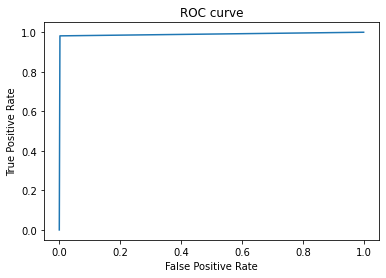

AUC value is 0.9897982557858599 


In [40]:
fpr, tpr, threshold= roc_curve(y_test, predicted, pos_label=1)
plt.plot(fpr, tpr)
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC curve")
plt.show()
print("AUC value is {} ".format(auc(fpr, tpr)))

In [41]:
x.shape

(1139754, 243)

In [42]:
del x_train, x_test, y_train, y_test

# Preprocessing of Testing Data

In [43]:
test.shape

(506691, 433)

In [44]:
for i in test.columns:
    if test[i].isnull().sum() / len(test) * 100 > 80:
#         print(i)
        test.drop(i, inplace = True, axis = 1)

In [45]:
test.isnull().sum()/len(test) * 100

TransactionID      0.000000
TransactionDT      0.000000
TransactionAmt     0.000000
ProductCD          0.000000
card1              0.000000
                    ...    
id-36             72.966364
id-37             72.966364
id-38             72.966364
DeviceType        72.975443
DeviceInfo        77.292472
Length: 362, dtype: float64

In [46]:
for i in test.columns:
    test[i] = test[i].fillna(test[i].mode()[0])

In [47]:
test.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 506691 entries, 0 to 506690
Columns: 362 entries, TransactionID to DeviceInfo
dtypes: float64(333), int64(3), object(26)
memory usage: 1.4+ GB


In [48]:
o = []
for i in test.columns:
    if test.dtypes[i] == 'O':
        o.append(i)
o

['ProductCD',
 'card4',
 'card6',
 'P_emaildomain',
 'R_emaildomain',
 'M1',
 'M2',
 'M3',
 'M4',
 'M5',
 'M6',
 'M7',
 'M8',
 'M9',
 'id-12',
 'id-15',
 'id-16',
 'id-28',
 'id-29',
 'id-31',
 'id-35',
 'id-36',
 'id-37',
 'id-38',
 'DeviceType',
 'DeviceInfo']

Converting objects into integers

In [49]:
for i in o:
    test[i] = la.fit_transform(test[i])

In [50]:
test.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 506691 entries, 0 to 506690
Columns: 362 entries, TransactionID to DeviceInfo
dtypes: float64(333), int64(29)
memory usage: 1.4 GB


In [51]:
l.remove('isFraud')
l

['V257',
 'V246',
 'V244',
 'V242',
 'V201',
 'V200',
 'V45',
 'V189',
 'V86',
 'V87',
 'V258',
 'V188',
 'V44',
 'V228',
 'V170',
 'V52',
 'V171',
 'V199',
 'V51',
 'V230',
 'V40',
 'V79',
 'V39',
 'V38',
 'V43',
 'V190',
 'V94',
 'V33',
 'V17',
 'V18',
 'V243',
 'V81',
 'V34',
 'V74',
 'V80',
 'V93',
 'V15',
 'V42',
 'V92',
 'card3',
 'V16',
 'V37',
 'V50',
 'V73',
 'V58',
 'V85',
 'V84',
 'V21',
 'V57',
 'V31',
 'V176',
 'V77',
 'V32',
 'V123',
 'V22',
 'V47',
 'V72',
 'V23',
 'V302',
 'V247',
 'V222',
 'V78',
 'V304',
 'V71',
 'V63',
 'V60',
 'V59',
 'V64',
 'V303',
 'V239',
 'V111',
 'V186',
 'V113',
 'V252',
 'V184',
 'V283',
 'V125',
 'V229',
 'V24',
 'V238',
 'V259',
 'V262',
 'V221',
 'V46',
 'V112',
 'V185',
 'V282',
 'V108',
 'V114',
 'V197',
 'V198',
 'V195',
 'V249',
 'V194',
 'V110',
 'V261',
 'V116',
 'V124',
 'V260',
 'V235',
 'V220',
 'V281',
 'V169',
 'V62',
 'V67',
 'V83',
 'V248',
 'V109',
 'V245',
 'V115',
 'V56',
 'V61',
 'V191',
 'V117',
 'V82',
 'V174',
 'V315',

# Making Predictions on Testing Data

In [52]:
x_test_pre = test[l]
predicted = ra.predict(x_test_pre)

In [53]:
x_test_pre.shape

(506691, 243)

In [56]:
submit = pd.DataFrame(data = {'TransactionID' : test_id, 'isFraud' :predicted})
submit

,TransactionID,isFraud
0,3663549,0
1,3663550,0
2,3663551,0
3,3663552,0
4,3663553,0
...,...,...
506686,4170235,0
506687,4170236,0
506688,4170237,0
506689,4170238,0


Saving the final results

In [57]:
submit.to_csv("submission1.csv", index = False)
submit.head()

,TransactionID,isFraud
0,3663549,0
1,3663550,0
2,3663551,0
3,3663552,0
4,3663553,0
